# Project No: 1                                                                  
# House Price Prediction

# Linear Regression

Linear regression is a supervised learning algorithm in machine learning that is used for predicting continuous numerical output values. It is a statistical method that is widely used for modeling the relationship between a dependent variable and one or more independent variables.                      


In linear regression, the goal is to find a linear relationship between the input variables (also known as features or independent variables) and the output variable (also known as the dependent variable). The linear relationship is represented by a linear equation of the form:


                                                          
 # y = mx + b
  
# y                                              
is the output variable,                                     
# x                                                          
is the input variable,                                                     
# m                                                              
is the slope of the line,                                                   
# b                                                                    
is the y-intercept.                                                 

The linear regression algorithm aims to find the values of m and b that minimize the error between the predicted output values and the actual output values.

The linear regression model can be used to make predictions on new data points by plugging in the input values into the linear equation and calculating the output value.

There are two main types of linear regression:

# simple linear regression                                                  
 In simple linear regression, there is only one input variable.                            
 
# multiple linear regression, 
there are multiple input variables.

Linear regression is widely used in various fields such as finance, economics, and social sciences to model and predict numerical data.




Regenerate response

# RMSE:                                                        
 It is the square root of mean squared error (MSE).
 
# MAE:                                           
It is an absolute sum of actual and predicted differences, but it lacks mathematically, that’s why it is rarely used, as compared to other metrics.                                                  



# steps                                  
1 Data Loading                              
2 Preprocessing                                 
3 Data analysis
4 Evaluation                                    
5 XGRregression                                       
6 Train Test split  
7 Model

In [5]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.4/101.7 MB 13.7 MB/s eta 0:00:08
   -- ------------------------------------- 5.5/101.7 MB 13.6 MB/s eta 0:00:08
   --- ------------------------------------ 8.7/101.7 MB 13.0 MB/s eta 0:00:08
   ---- ----------------------------------- 11.0/101.7 MB 13.1 MB/s eta 0:00:07
   ----- ---------------------------------- 13.6/101.7 MB 12.7 MB/s eta 0:00:07
   ------ --------------------------------- 16.8/101.7 MB 13.0 MB/s eta 0:00:07
   ------- -------------------------------- 20.2/101.7 MB 13.4 MB/s eta 0:00:07
   --------- ------------------------------ 24.1/101.7 MB 14.0 MB/s eta 0:00:06
   ---------- ----------------------------- 27.0/101.7 MB 13.9 MB/s eta 0:00:06
   ----------- ---------------------------- 28.8/101.7 MB 13.4 MB/s eta 0:00:06
   ----------- ---------------------------- 30.4/101.7 MB 13.

# House Price Prediction Project
# Using XGBoost Regression

# 1. DATA LOADING




In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor

# Load Dataset
data = pd.read_csv("housing.csv")

print("First 5 Rows:")
print(data.head())

First 5 Rows:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


# 2. PREPROCESSING



In [10]:
# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Remove duplicates
data = data.drop_duplicates()

# Features and Target
X = data.drop("medv", axis=1)
y = data["medv"]

print("\nDataset Shape:")
print(data.shape)


Missing Values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Dataset Shape:
(506, 14)



# 3. DATA ANALYSIS




Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None

Statistical Summary:
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.3

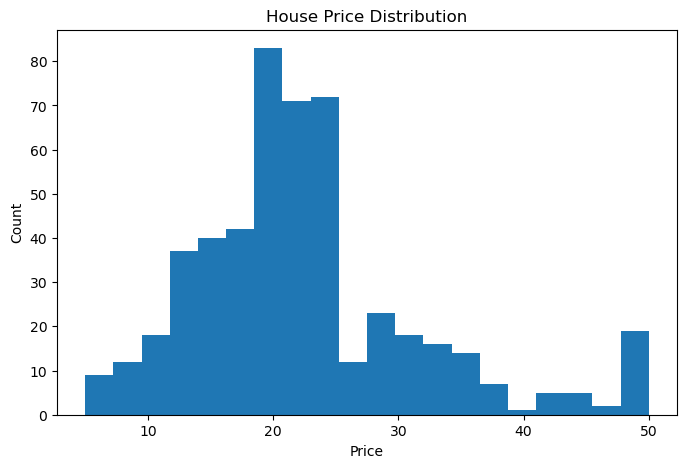

In [11]:
print("\nDataset Information:")
print(data.info())

print("\nStatistical Summary:")
print(data.describe())

# Plot House Price Distribution
plt.figure(figsize=(8,5))
plt.hist(y, bins=20)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()



# 4. TRAIN TEST SPLIT


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)




Training Data Shape: (404, 13)
Testing Data Shape: (102, 13)


# 5. XGBOOST REGRESSION


In [19]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

# 6. MODEL TRAINING



In [15]:

model.fit(X_train, y_train)

print("\nModel Training Completed!")




Model Training Completed!


# 7. EVALUATION

In [16]:
# Prediction
y_pred = model.predict(X_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2 Score
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("RMSE:", rmse)
print("R2 Score:", r2)



Model Evaluation
RMSE: 2.6313434017245765
R2 Score: 0.9055828323671475


# SAMPLE PREDICTION

In [17]:

sample = X.iloc[0:1]

prediction = model.predict(sample)

print("\nSample House Price Prediction:")
print(prediction)


Sample House Price Prediction:
[28.189043]


# ACTUAL VS PREDICTED GRAPH

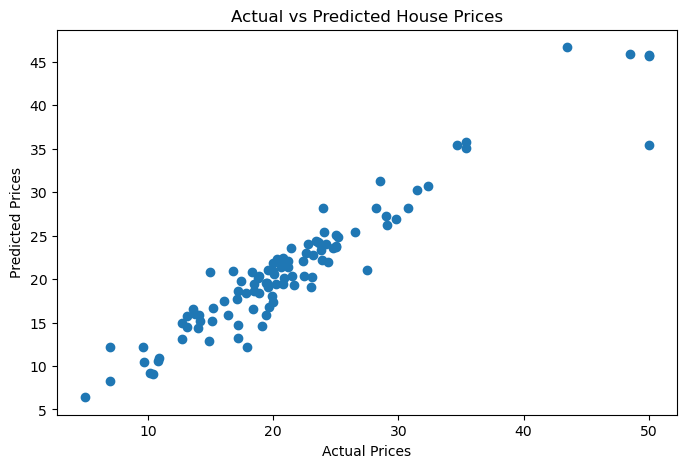

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()